In [2]:
import numpy as np
import scipy as sp
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.pyplot as plt

## Bisection Method



In [3]:
def bisection(f, a, b, tol=1e-7):
    if f(a) * f(b) >= 0:
        return None
    for _ in range(100):
        mid = (a + b) / 2
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2

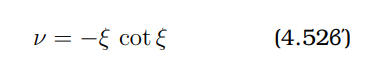

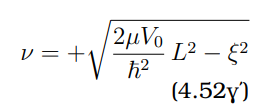

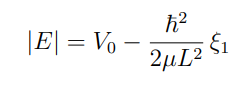

In [ ]:
def find_best_fit_bis():
    h2_2m = 20.435  # MeV * fm^2
    E_exp = 2.222    # Experimental Binding Energy for Deuteron (MeV)
    
    # Ranges
    v0_range = np.linspace(1, 30, 100)
    l_range = np.linspace(1, 10, 100)
    
    best_pair = None
    min_error = float('inf')

    # Scanning 100 * 100 = 10,000 combinations of V0,L
    for v0 in v0_range:
        for l in l_range:
            # 1. Check your inequality constraint
            C = (v0 * l**2) / h2_2m
            if (np.pi**2 / 4) <= C <= (9 * np.pi**2 / 4):
                
                # 2. Define the function of xi (4.52b = 4.52c)
                def f(xi):
                    return np.sqrt(C - xi**2) + xi * (np.cos(xi) / np.sin(xi))

                # 3. Solve for xi
                xi_sol = bisection(f, np.pi/2 + 1e-5, np.sqrt(C) - 1e-5)
                
                if xi_sol:
                    # 4. Calculate numerical Binding Energy
                    e_num = v0 - (h2_2m * (xi_sol**2 / l**2))
                    
                    # 5. Compare with Experimental Value
                    error = abs(e_num - E_exp)
                    if error < min_error:
                        min_error = error
                        best_pair = {
                            'V0': v0,
                            'L': l,
                            'xi': xi_sol,
                            'E_num': e_num,
                            'error': error
                        }

    # Output Results
    if best_pair:
        print("--- Best Fit Found ---")
        print(f"V0 (Potential Depth): {best_pair['V0']:.4f} MeV")
        print(f"L (Well Width):      {best_pair['L']:.4f} fm")
        print(f"xi value:        {best_pair['xi']:.4f}")
        print(f"Numerical Energy:    {best_pair['E_num']:.4f} MeV")
        print(f"Experimental Energy: {E_exp} MeV")
        print(f"Absolute Error:      {best_pair['error']:.6f} MeV")
        print(f"Relative Error:      {(best_pair['error']/E_exp)*100:.4f}%")
    else:
        print("No pairs satisfied the constraints within the given ranges.")

In [5]:
find_best_fit_bis()

--- Best Fit Found ---
V0 (Potential Depth): 5.6869 MeV
L (Well Width):      5.4545 fm
xi value:        2.2460
Numerical Energy:    2.2220 MeV
Experimental Energy: 2.222 MeV
Absolute Error:      0.000009 MeV
Relative Error:      0.0004%


## Fsolve default method

Correct results but it returns invalid value encountered in sqrt due to the limitation in setting boundaries

In [6]:
def find_best_fit_fsolve():
    h2_2m = 20.435  # MeV * fm^2
    E_exp = 2.2220    # Experimental Binding Energy for Deuteron (MeV)
    
    # Ranges
    v0_range = np.linspace(1, 30, 100)
    l_range = np.linspace(1, 10, 100)
    
    best_pair = None
    min_error = float('inf')

    # Scanning 100 * 100 = 10,000 combinations of V0,L
    for v0 in v0_range:
        for l in l_range:
            # 1. Check your inequality constraint
            C = (v0 * l**2) / h2_2m
            if (np.pi**2 / 4) <= C <= (9 * np.pi**2 / 4):
                
                # 2. Define the function of xi
                def f(xi):
                    return np.sqrt(C - xi**2) + xi * (np.cos(xi) / np.sin(xi))

                # 3. Solve for xi
                initial_guess = (np.pi/2 + np.sqrt(C)) / 2 #median
                xi_sol = fsolve(f, initial_guess)[0]
                
                if xi_sol:
                    # 4. Calculate numerical Binding Energy
                    e_num = v0 - (h2_2m * (xi_sol**2 / l**2))
                    
                    # 5. Compare with Experimental Value
                    error = abs(e_num - E_exp)
                    if error < min_error:
                        min_error = error
                        best_pair = {
                            'V0': v0,
                            'L': l,
                            'xi': xi_sol,
                            'E_num': e_num,
                            'error': error
                        }

    # Output Results
    if best_pair:
        print("--- Best Fit Found ---")
        print(f"V0 (Potential Depth): {best_pair['V0']:.4f} MeV")
        print(f"L (Well Width):      {best_pair['L']:.4f} fm")
        print(f"xi value:        {best_pair['xi']:.4f}")
        print(f"Numerical Energy:    {best_pair['E_num']:.4f} MeV")
        print(f"Experimental Energy: {E_exp} MeV")
        print(f"Absolute Error:      {best_pair['error']:.6f} MeV")
        print(f"Relative Error:      {(best_pair['error']/E_exp)*100:.4f}%")
    else:
        print("No pairs satisfied the constraints within the given ranges.")

In [7]:
find_best_fit_fsolve()

C:\Users\Owner\AppData\Local\Temp\ipykernel_30040\1434754959.py:21: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(C - xi**2) + xi * (np.cos(xi) / np.sin(xi))
C:\Users\Owner\AppData\Local\Temp\ipykernel_30040\1434754959.py:25: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  xi_sol = fsolve(f, initial_guess)[0]


--- Best Fit Found ---
V0 (Potential Depth): 5.6869 MeV
L (Well Width):      5.4545 fm
xi value:        2.2460
Numerical Energy:    2.2220 MeV
Experimental Energy: 2.222 MeV
Absolute Error:      0.000009 MeV
Relative Error:      0.0004%


## Brent's method
Allows to set boundaries

In [ ]:
def find_best_fit_brentq():
    # Physical Constants
    h2_2m = 20.435  # MeV * fm^2
    E_exp = 2.2220   # Experimental target (MeV)
    
    # Ranges for Scanning
    v0_range = np.linspace(1, 30, 100)
    l_range = np.linspace(1, 10, 100)
    
    best_pair = None
    min_error = float('inf')

    for v0 in v0_range:
        for l in l_range:
            C = (v0 * l**2) / h2_2m
            
            # Constraint
            if (np.pi**2 / 4) <= C <= (9 * np.pi**2 / 4):
                
                def f(xi):
                    return np.sqrt(C - xi**2) + xi * (np.cos(xi) / np.sin(xi))

                # Adding 1e-7 prevents division by zero at sin(pi) and avoids sqrt of a negative number
                lower = np.pi/2 + 1e-7
                upper = np.sqrt(C) - 1e-7
                
                try:
                    # brentq finds the root within the interval [lower, upper]
                    xi_sol = brentq(f, lower, upper)
                    
                    # Calculate Energy
                    e_num = v0 - (h2_2m * (xi_sol**2 / l**2))
                    error = abs(e_num - E_exp)
                    
                    if error < min_error:
                        min_error = error
                        best_pair = {'V0': v0, 'L': l, 'xi': xi_sol, 'E_num': e_num}
                except ValueError:
                    # Occurs if f(lower) and f(upper) have the same sign
                    continue

    # Output Results
    if best_pair:
        print("--- Best Fit Found ---")
        print(f"V0 (Potential Depth): {best_pair['V0']:.4f} MeV")
        print(f"L (Well Width):      {best_pair['L']:.4f} fm")
        print(f"xi value:        {best_pair['xi']:.4f}")
        print(f"Numerical Energy:    {best_pair['E_num']:.4f} MeV")
        print(f"Experimental Energy: {E_exp} MeV")
    else:
        print("No pairs satisfied the constraints within the given ranges.")

In [22]:
find_best_fit_brentq()

--- Best Fit Found ---
V0 (Potential Depth): 5.6869 MeV
L (Well Width):      5.4545 fm
xi value:        2.2460
Numerical Energy:    2.2220 MeV
Experimental Energy: 2.222 MeV


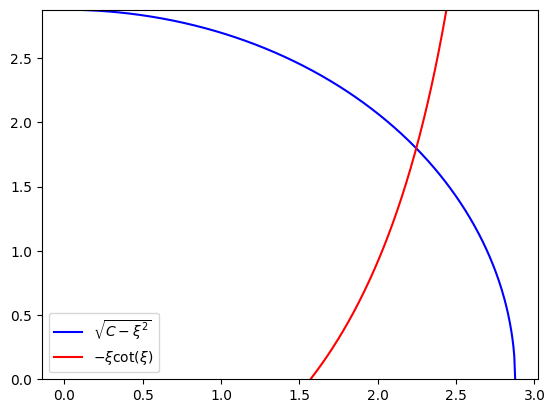

In [10]:
v0_best= 5.6859
l_best = 5.4545

h2_2m = 20.435

C_best = (v0_best * l_best**2) / h2_2m

xi_plot = np.linspace(0.01, np.sqrt(C_best), 500) # Avoid division by zero by shifting starting point from 0 to 0.01
xi_circle = np.linspace(0, np.sqrt(C_best), 500)

y_circle = np.sqrt(C_best - xi_circle**2)
y_cot = -xi_plot * (np.cos(xi_plot) / np.sin(xi_plot))

plt.plot(xi_circle, y_circle, 'b-',label=r'$\sqrt{C - \xi^2}$')
plt.plot(xi_plot, y_cot, 'r-', label=r'$-\xi \cot(\xi)$')
plt.ylim(0, np.sqrt(C_best))
plt.legend()
plt.show()